# Hypermethylation

## Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import minimize_scalar
from scipy.stats import betabinom


DATA_DIR = Path("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/data")
METADATA_DIR = Path("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/metadata")
OUTPUT_DIR = Path("/lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/output")

METH_MATRIX = DATA_DIR / "per_chr/11_meth_count_matrix.parquet"
TOTAL_MATRIX = DATA_DIR / "per_chr/11_total_matrix.parquet"
COHORT_PATH = METADATA_DIR / "cohort_26_02_06.csv"
OUTPUT_PATH = OUTPUT_DIR / "h19_hypermethylation_GRCh37.csv"

REGION_START = 2_019_975
REGION_END = 2_024_739
P0 = 0.5
MIN_COVERAGE = 5
P_VALUE_THRESHOLD = 0.05
NORMAL_BETA_MAX = 0.8

ICR1_PATTERN = (
    r"beckwith|\bbws\b|11p15|11p |igf2|h19|icr1|"
    r"hemi-?hyper|overgrowth|kcnq1|cdkn1c"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Sample metadata

In [2]:
def read_cohort(path):
    cohort = pd.read_csv(path, low_memory=False)
    if "DNA_ID" not in cohort.columns:
        cohort = pd.read_csv(path, low_memory=False, skiprows=1)
    return cohort


meth_columns = pl.scan_parquet(METH_MATRIX).collect_schema().names()
total_columns = set(pl.scan_parquet(TOTAL_MATRIX).collect_schema().names())
sample_columns = [
    column for column in meth_columns
    if column != "start" and column in total_columns
]

samples = pd.DataFrame({"sample": sample_columns})
samples["dna_id"] = samples["sample"].str.replace(
    r"_lo0001$", "", regex=True
)

cohort = (
    read_cohort(COHORT_PATH)
    .drop_duplicates("DNA_ID")
    .set_index("DNA_ID")
)

metadata_columns = {
    "Tumour_Normal": "type",
    "Predisposition_details": "predisposition_detail",
    "Diagnosis": "diagnosis",
    "Diagnostic_group": "diagnostic_group",
    "Histology_overall": "histology",
    "Tissue": "tissue",
    "Sample_type": "sample_type",
    "EMseq_Project": "project",
}

metadata = samples.join(
    cohort[list(metadata_columns)].rename(columns=metadata_columns),
    on="dna_id",
)
metadata["type"] = metadata["type"].astype("string").str.strip().str.lower()
metadata["icr1_related"] = (
    metadata["predisposition_detail"]
    .fillna("")
    .astype(str)
    .str.contains(ICR1_PATTERN, case=False, regex=True)
)

## Regional methylation

In [3]:
def load_region(path):
    return (
        pl.scan_parquet(path)
        .filter(pl.col("start").is_between(REGION_START, REGION_END))
        .collect()
        .sort("start")
    )


meth_region = load_region(METH_MATRIX)
total_region = load_region(TOTAL_MATRIX)

shared_positions = sorted(
    set(meth_region["start"].to_list())
    & set(total_region["start"].to_list())
)

if not shared_positions:
    raise ValueError("No CpG positions were found in the specified region")

meth_region = meth_region.filter(pl.col("start").is_in(shared_positions))
total_region = total_region.filter(pl.col("start").is_in(shared_positions))

region_counts = pd.DataFrame({
    "sample": sample_columns,
    "methylated_count": np.asarray(
        meth_region.select(sample_columns).sum().row(0), dtype=int
    ),
    "total_count": np.asarray(
        total_region.select(sample_columns).sum().row(0), dtype=int
    ),
})

region_counts["beta"] = np.divide(
    region_counts["methylated_count"],
    region_counts["total_count"],
    out=np.full(len(region_counts), np.nan),
    where=region_counts["total_count"].ne(0),
)

results = metadata.merge(region_counts, on="sample", how="inner")

## Beta-binomial model

In [4]:
baseline = results.loc[
    results["type"].eq("normal")
    & ~results["icr1_related"]
    & results["total_count"].gt(0)
    & results["beta"].le(NORMAL_BETA_MAX)
]

if baseline.empty:
    raise ValueError("No normal samples are available for dispersion estimation")

baseline_methylated = baseline["methylated_count"].to_numpy()
baseline_total = baseline["total_count"].to_numpy()


def negative_log_likelihood(log_kappa):
    kappa = np.exp(log_kappa)
    return -betabinom.logpmf(
        baseline_methylated,
        baseline_total,
        P0 * kappa,
        (1 - P0) * kappa,
    ).sum()


fit = minimize_scalar(
    negative_log_likelihood,
    bounds=(np.log(1), np.log(1e6)),
    method="bounded",
)

kappa = float(np.exp(fit.x))
alpha = P0 * kappa
beta_shape = (1 - P0) * kappa

print(f"Normal samples: {len(baseline)}")
print(f"Estimated kappa: {kappa:.3f}")

Normal samples: 111
Estimated kappa: 17.433


## Hypermethylation calls

In [5]:
covered = results["total_count"].gt(0)
results["p_value"] = np.nan
results.loc[covered, "p_value"] = betabinom.sf(
    results.loc[covered, "methylated_count"].to_numpy() - 1,
    results.loc[covered, "total_count"].to_numpy(),
    alpha,
    beta_shape,
)

results["delta_beta"] = results["beta"] - P0
results["hypermethylated"] = (
    results["total_count"].ge(MIN_COVERAGE)
    & results["beta"].gt(P0)
    & results["p_value"].le(P_VALUE_THRESHOLD)
).fillna(False)

print(f"Hypermethylated samples: {results['hypermethylated'].sum()} / {len(results)}")

Hypermethylated samples: 219 / 506


## Violin plot

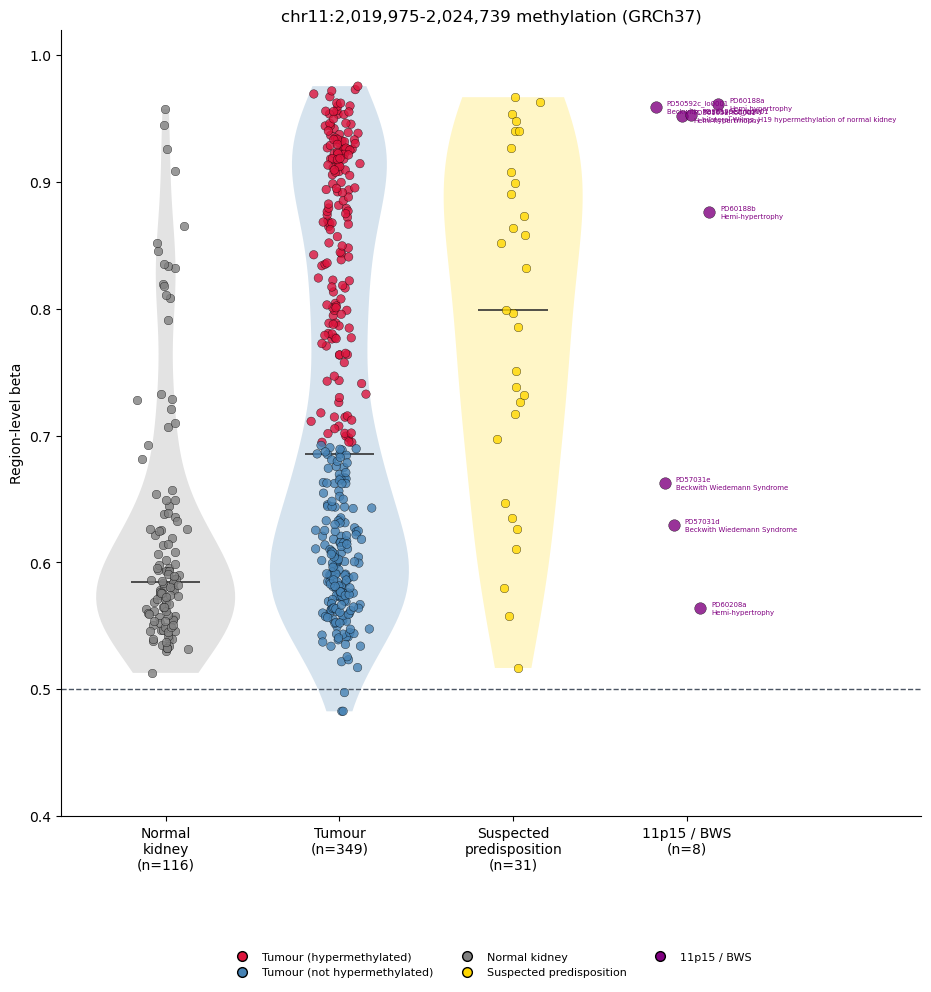

In [7]:
MIN_REGION_COVERAGE_PLOT = 10

known = (
    cohort["Predisposition_known?"]
    .reindex(results["dna_id"])
    .astype(str).str.strip().str.lower().to_numpy()
)
suspected = (
    cohort["Predisposition_suspected?"]
    .reindex(results["dna_id"])
    .astype(str).str.strip().str.lower().to_numpy()
)
results["suspected"] = (suspected == "yes") & (known != "yes")
results["plot_group"] = np.select(
    [
        results["icr1_related"].fillna(False).to_numpy(dtype=bool),
        results["suspected"].fillna(False).to_numpy(dtype=bool),
        results["type"].eq("tumour").fillna(False).to_numpy(dtype=bool),
        results["type"].eq("normal").fillna(False).to_numpy(dtype=bool),
    ],
    ["ICR1", "Suspected", "Tumour", "Normal"],
    default="Other",
)

plot_df = results.loc[
    results["total_count"].ge(MIN_REGION_COVERAGE_PLOT)
    & np.isfinite(results["beta"])
].copy()

group_order = ["Normal", "Tumour", "Suspected", "ICR1"]
group_labels = {
    "Normal": "Normal\nkidney",
    "Tumour": "Tumour",
    "Suspected": "Suspected\npredisposition",
    "ICR1": "11p15 / BWS",
}
group_colours = {
    "Normal": "grey",
    "Tumour": "steelblue",
    "Suspected": "gold",
    "ICR1": "purple",
}

plot_df = plot_df.loc[plot_df["plot_group"].isin(group_order)].copy()
grouped = {
    group: plot_df.loc[plot_df["plot_group"].eq(group), "beta"].dropna().to_numpy()
    for group in group_order
}

fig, ax = plt.subplots(figsize=(9.5, 10))
violin_groups = [
    group for group in group_order
    if group != "ICR1" and len(grouped[group]) >= 6 and np.ptp(grouped[group]) > 0
]

if violin_groups:
    parts = ax.violinplot(
        [grouped[group] for group in violin_groups],
        positions=[group_order.index(group) for group in violin_groups],
        widths=0.8, showmeans=False, showmedians=True, showextrema=False,
    )
    for body, group in zip(parts["bodies"], violin_groups):
        body.set_facecolor(group_colours[group])
        body.set_alpha(0.22)
        body.set_edgecolor("none")
    parts["cmedians"].set_color("#333333")
    parts["cmedians"].set_linewidth(1.2)

rng = np.random.default_rng(1)
for position, group in enumerate(group_order):
    subset = plot_df.loc[plot_df["plot_group"].eq(group)]
    if subset.empty:
        continue

    offsets = (
        np.linspace(-0.18, 0.18, len(subset))
        if group == "ICR1" and len(subset) > 1
        else rng.normal(0, 0.06 if len(subset) > 10 else 0.025, len(subset))
    )
    x = position + offsets
    colours = (
        np.where(subset["hypermethylated"], "crimson", "steelblue")
        if group == "Tumour"
        else group_colours[group]
    )
    ax.scatter(
        x, subset["beta"], c=colours, s=70 if group == "ICR1" else 38,
        alpha=0.8, edgecolor="black", linewidth=0.3, zorder=3,
    )

    if group == "ICR1":
        for x_value, row in zip(x, subset.itertuples()):
            ax.annotate(
                f"{row.sample}\n{row.predisposition_detail}",
                (x_value, row.beta), textcoords="offset points", xytext=(8, 0),
                fontsize=5, color=group_colours[group], ha="left", va="center",
            )

ax.axhline(P0, linestyle="--", linewidth=1, color="#4B5563")
ax.set_xticks(np.arange(len(group_order)))
ax.set_xticklabels([
    f"{group_labels[group]}\n(n={len(grouped[group])})" for group in group_order
])
ax.set_xlim(-0.6, len(group_order) - 0.4 + 0.75)
ax.set_ylim(0.4, 1.02)
ax.set_ylabel("Region-level beta")
ax.spines[["top", "right"]].set_visible(False)
ax.set_title(f"chr11:{REGION_START:,}-{REGION_END:,} methylation (GRCh37)")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="crimson",
               markeredgecolor="black", markersize=7, label="Tumour (hypermethylated)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
               markeredgecolor="black", markersize=7, label="Tumour (not hypermethylated)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="grey",
               markeredgecolor="black", markersize=7, label="Normal kidney"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gold",
               markeredgecolor="black", markersize=7, label="Suspected predisposition"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="purple",
               markeredgecolor="black", markersize=7, label="11p15 / BWS"),
    ],
    frameon=False, fontsize=8, loc="upper center",
    bbox_to_anchor=(0.5, -0.16), ncol=3,
)

plt.tight_layout()
for extension in ("pdf", "png"):
    fig.savefig(
        OUTPUT_DIR / f"h19_hypermethylation_violin_GRCh37.{extension}",
        bbox_inches="tight", dpi=600,
    )
plt.show()

## Output

In [8]:
output_columns = [
    "sample",
    "dna_id",
    "type",
    "diagnosis",
    "diagnostic_group",
    "histology",
    "tissue",
    "sample_type",
    "project",
    "predisposition_detail",
    "icr1_related",
    "methylated_count",
    "total_count",
    "beta",
    "delta_beta",
    "p_value",
    "hypermethylated",
]

results[output_columns].to_csv(OUTPUT_PATH, index=False)
print(f"Written: {OUTPUT_PATH}")

Written: /lustre/scratch125/cellgen/behjati/project_folders/wilms_EMSeq/output/h19_hypermethylation_GRCh37.csv
